# 06 Random Forest With Basic Image Features

This notebook trains a basic `RandomForestClassifier`, then tunes only the Random Forest model family using grouped cross-validation on the training split. A random forest averages many decision trees, which can reduce the variance of a single tree while still using nonlinear feature thresholds.


## 1. Project setup

In [22]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

## 2. Imports

In [23]:
from src.extract_basic_features import BASIC_FEATURE_COLUMNS
from src.train_logistic_regression import FEATURES_CSV, load_features
from src.train_random_forest import (
    BASIC_SCORES_CSV,
    BASIC_CONFUSION_MATRIX_FIGURE,
    BASIC_FEATURE_IMPORTANCE_CSV,
    BASIC_FEATURE_IMPORTANCE_FIGURE,
    TUNED_SCORES_CSV,
    TUNED_CONFUSION_MATRIX_FIGURE,
    TUNED_FEATURE_IMPORTANCE_CSV,
    TUNED_FEATURE_IMPORTANCE_FIGURE,
    build_comparison_table,
    print_overfitting_summary,
    train_random_forest,
)


## 3. Paths and configuration

In [24]:
print(f"Basic features CSV: {FEATURES_CSV}")
print(f"Basic scores CSV: {BASIC_SCORES_CSV}")
print(f"Tuned scores CSV: {TUNED_SCORES_CSV}")
print(f"Basic confusion matrix figure: {BASIC_CONFUSION_MATRIX_FIGURE}")
print(f"Tuned confusion matrix figure: {TUNED_CONFUSION_MATRIX_FIGURE}")
print(f"Basic feature importance CSV: {BASIC_FEATURE_IMPORTANCE_CSV}")
print(f"Tuned feature importance CSV: {TUNED_FEATURE_IMPORTANCE_CSV}")


Basic features CSV: /home/jp/MSE446_Nanoparticle_Ordering/data/features_basic.csv
Scores CSV: /home/jp/MSE446_Nanoparticle_Ordering/results/model_scores_random_forest_basic.csv
Confusion matrix figure: /home/jp/MSE446_Nanoparticle_Ordering/results/figures/confusion_matrix_random_forest_basic.png
Feature importance CSV: /home/jp/MSE446_Nanoparticle_Ordering/results/feature_importance_random_forest_basic.csv
Feature importance figure: /home/jp/MSE446_Nanoparticle_Ordering/results/figures/feature_importance_random_forest_basic.png


## 4. Load metadata

In [25]:
features = load_features(FEATURES_CSV)
features.head()

,filename,label,sample,area,area_group,kv,mm,mag,param_group,mean_intensity,...,min_intensity,max_intensity,p10_intensity,p25_intensity,p50_intensity,p75_intensity,p90_intensity,entropy,bright_pixel_ratio,edge_density
0,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.354890,...,0.160784,0.964706,0.266667,0.298039,0.345098,0.396078,0.447059,6.260059,0.099014,0.161224
1,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.414923,...,0.094118,1.000000,0.329412,0.376471,0.407843,0.447059,0.486275,6.191408,0.098190,0.113770
2,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.311404,...,0.141176,1.000000,0.247059,0.266667,0.286275,0.317647,0.423529,5.814114,0.097717,0.160583
3,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.326249,...,0.113725,1.000000,0.235294,0.266667,0.313726,0.368627,0.419608,6.261398,0.098694,0.164108
4,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.260067,...,0.000000,1.000000,0.117647,0.176471,0.235294,0.294118,0.415686,6.846660,0.099258,0.171616


## 5. Sanity checks

In [26]:
print(f"Rows: {len(features)}")
print("Label counts:")
print(features["label"].value_counts().sort_index())
print(f"Image feature columns: {len(BASIC_FEATURE_COLUMNS)}")
assert set(BASIC_FEATURE_COLUMNS).issubset(features.columns)
assert features["area_group"].notna().all()

Rows: 1000
Label counts:
label
disordered    250
ordered       750
Name: count, dtype: int64
Image feature columns: 12


## 6. Main analysis

The same selected grouped train/test split logic is reused. Metadata is not used as a predictor; only the basic image feature columns go into `X`. The tuned Random Forest uses `GridSearchCV` with `GroupKFold` on the training set only, scored by macro F1.


In [27]:
(
    basic_scores,
    basic_report,
    basic_matrix,
    basic_matrix_path,
    basic_importance,
    basic_importance_csv,
    basic_importance_figure,
    tuned_scores,
    tuned_report,
    tuned_matrix,
    tuned_matrix_path,
    tuned_importance,
    tuned_importance_csv,
    tuned_importance_figure,
    y_train,
    y_test,
    search,
) = train_random_forest(features)

basic_scores


,model,train_accuracy,test_accuracy,train_balanced_accuracy,test_balanced_accuracy,train_macro_precision,macro_precision,train_macro_recall,macro_recall,train_macro_f1,macro_f1,disordered_recall,selected_split_seed,split_distribution_distance,n_estimators,max_depth,min_samples_leaf,train_size,test_size
0,random_forest_basic,1.0,0.885135,1.0,0.842342,1.0,0.84871,1.0,0.842342,1.0,0.845445,0.756757,140,0.0,200,None,1,852,148


## 7. Results/figures

Per-class precision/recall/F1:
              precision    recall  f1-score   support

  disordered       0.78      0.76      0.77        37
     ordered       0.92      0.93      0.92       111

    accuracy                           0.89       148
   macro avg       0.85      0.84      0.85       148
weighted avg       0.88      0.89      0.88       148

Top feature importances:
               feature  importance
0         edge_density    0.225822
1        min_intensity    0.160004
2        std_intensity    0.115243
3        p10_intensity    0.091742
4   bright_pixel_ratio    0.074473
5              entropy    0.064386
6        p25_intensity    0.052656
7        p90_intensity    0.049874
8       mean_intensity    0.045792
9        p75_intensity    0.045534
10       p50_intensity    0.042534
11       max_intensity    0.031941
Model comparison:
                  model  test_accuracy  test_balanced_accuracy  macro_f1  \
0       DummyClassifier       0.885787                0.500000  0.46

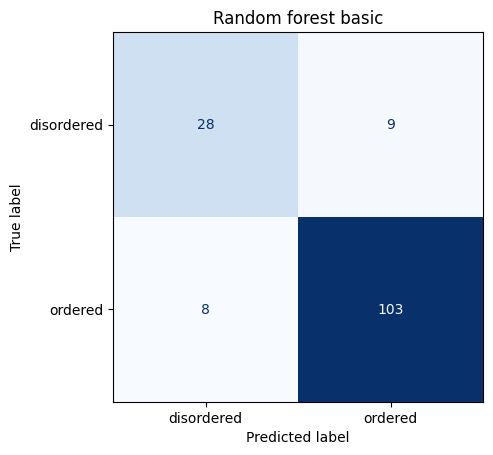

In [28]:
basic_scores.to_csv(BASIC_SCORES_CSV, index=False)
tuned_scores.to_csv(TUNED_SCORES_CSV, index=False)

print("Basic Random Forest per-class precision/recall/F1:")
print(basic_report)
print("Tuned Random Forest per-class precision/recall/F1:")
print(tuned_report)

print_overfitting_summary(basic_scores, "Basic Random Forest")
print_overfitting_summary(tuned_scores, "Tuned Random Forest")

tuned_row = tuned_scores.iloc[0]
print("\nTuning summary:")
print(f"Best parameters: {search.best_params_}")
print(f"Best CV macro F1: {search.best_score_:.4f}")
print(f"Final test macro F1: {tuned_row['macro_f1']:.4f}")
print(f"Final test balanced accuracy: {tuned_row['test_balanced_accuracy']:.4f}")
print(f"Disordered recall: {tuned_row['disordered_recall']:.4f}")

print("\nBasic feature importances:")
print(basic_importance.head(12))
print("\nTuned feature importances:")
print(tuned_importance.head(12))
print("\nModel comparison:")
print(build_comparison_table(basic_scores, tuned_scores))

print(f"Saved basic scores to {BASIC_SCORES_CSV}")
print(f"Saved tuned scores to {TUNED_SCORES_CSV}")
print(f"Saved basic confusion matrix to {basic_matrix_path}")
print(f"Saved tuned confusion matrix to {tuned_matrix_path}")
print(f"Saved basic feature importance CSV to {basic_importance_csv}")
print(f"Saved tuned feature importance CSV to {tuned_importance_csv}")
print(f"Saved basic feature importance figure to {basic_importance_figure}")
print(f"Saved tuned feature importance figure to {tuned_importance_figure}")

tuned_scores


## 8. Notes for report

- The basic Random Forest uses fixed reasonable defaults.
- The tuned Random Forest uses grouped cross-validation on the training set only, scored by macro F1 because the labels are imbalanced.
- Compare train and test metrics to check whether tuning reduces overfitting rather than only increasing raw accuracy.
- Feature importance is impurity-based and should be interpreted as a model diagnostic, not physical proof of ordering.
- This step does not add SVC, KNN, GaussianNB, HOG, graph features, augmentation, or CNNs.
